# Load Libraries

In [22]:

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed
import os

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Doawnload data

In [16]:
"""
mre_run_solo.py

Minimal-but-complete MRE to run the SOLO pipeline with the new 
Edge-to-Edge Interpolating Tone Removal natively integrated.

RUN FROM REPO ROOT (the directory that contains: pyspedas/, functions/, download_data.py)
"""

import os
from pathlib import Path
from joblib import Parallel, delayed

# Import the main pipeline downloader
# (Adjust this import if your main script is named differently, e.g., import pipeline as download)
import download_data as download 

# ---------------------------------------------------------------------
# Base Paths
# ---------------------------------------------------------------------
# Define root_dir so the Path calls below work
root_dir = r"C:\Users\nokni\work\MHDTurbPy"

# CDFlib path (needed for SOLO distance download via CDAS)
cdf_lib_path = "/Applications/cdf/cdf/lib"

# Credentials (None is fine for SOLO in most cases)
credentials = None

# How many cores to use
n_jobs     = 1

# ---------------------------------------------------------------------
# Settings (organized by topic, then flattened into one dict)
# ---------------------------------------------------------------------
Paths = {
        "Data_path"         : Path(root_dir).joinpath('data'),
        #"save_destination"  : Path(root_dir).joinpath('examples').joinpath('backmap'),
        "save_destination"  : Path(root_dir).joinpath('examples').joinpath('noise_removal'),
        #"SOLO_dist_path"   : "/Users/turbulator/work/turb_amplitudes/SOLO/solo_dist.pkl",
}

Mission = { 
    "sc"             : "SOLO",
    "in_rtn"         : True,
    "use_local_data" : False,

    "SOLO_use_merged_MAG" : True,   # set False to use SPEDAS L2 MAG
    "SOLO_merged_fs"      : 256,    # 256 or 4096
}

# ---------------------------------------------------------------------
# SOLO-only MAG/SCM tone removal (single input)
# ---------------------------------------------------------------------
MAG_NOISE = {
    "Mag_SCM_SOLO": {
        "noise_flag": False,
        "noise_removal": {
            "method": "ola_fft_cap_auto",
        },
    }
}

Intervals = {
    "start_date": "2022-12-01 00:00",
    "end_date": "2022-12-01 01:00",
    
    "multiple_intervals": False,   # False -> single interval, True -> use Step/duration below
    "duration": "30d",
    "Step": "30d",
    "addit_time_around": 1,        # hours padding in LoadTimeSeriesSOLO
}

Sampling = {
    "part_resol":100,
    "MAG_resol": 1,
    "upsample_low_freq_ts": False,
}

QualityControl = {
    "overwrite_files"   :  1,
    "must_have_qtn": False,
    "Max_par_missing": 30,
    "gap_time_threshold": 5,
    "use_hampel": False,
    "hampel_params": {"w": 200, "std": 3},
}

Output = {
    "save_all": True,
    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

Diagnostics = {
    "estimate_derived_param": True,
    "rol_window": "60min",

    "PSDs": {"flag": False},
    "struc_funcs": {"flag": False},

    "npt_struc_funcs": {
        "flag": False,
        "five_points_sfunc": True,
        "return_Bmod": True,
        "dt_step": 0.25,
        "est_sfuncs": False,
        "max_qorder": 8,
    },

    "estimate_psd_b": True,
    "estimate_psd_v": True,
    "est_PSD_components": True,
    "smooth_psd": False,
}

Gaps = {
    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 500,
        "Par_big_gaps": 500,
        "QTN_big_gaps": 10,
    }
}

# ---- final settings dict (what pipeline consumes)
settings = {
    **Paths,
    **Mission,
    **Intervals,
    **Sampling,
    **QualityControl,
    **Output,
    **Diagnostics,

    **MAG_NOISE,
    "Big_Gaps": Gaps["Big_Gaps"],
}

# ---------------------------------------------------------------------
# What variables to download (None -> defaults inside SOLO.py)
# ---------------------------------------------------------------------
vars_2_downnload = {
    "mag": None,
    "swa": None,
    "rpw": None,
    "ephem": None,
}

# ---------------------------------------------------------------------
# Interval generation
# ---------------------------------------------------------------------
if __name__ == '__main__':
    generated_interval_list = download.generate_intervals(
        settings["start_date"],
        settings["end_date"],
        settings["multiple_intervals"],
        data_path=settings["Data_path"],
        settings=settings,
    )

    # ---------------------------------------------------------------------
    # Run download for each interval
    # ---------------------------------------------------------------------
    os.chdir(settings["Data_path"])

    save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
    save_path.mkdir(parents=True, exist_ok=True)

    print(
        f"Starting pipeline on {len(generated_interval_list)} interval(s) "
        f"(tone removal noise_flag={bool(settings.get('Mag_SCM_SOLO', {}).get('noise_flag', False))})."
    )

    Parallel(n_jobs=n_jobs)(
        delayed(download.download_files)(
            jj,
            generated_interval_list,
            settings,
            vars_2_downnload,
            cdf_lib_path,
            credentials,
            save_path,
        )
        for jj in range(len(generated_interval_list))
    )
    
    print("Pipeline complete.")

05-Mar-26 07:01:58: Generating only one interval based on the provided start and end times.
05-Mar-26 07:01:58: Start Time: 2022-12-01 00:00:00
End Time: 2022-12-01 01:00:0000

05-Mar-26 07:01:58: Considering a single interval spanning: 2022-12-01 00:00:00 to 2022-12-01 01:00:00
Creating new folder  C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\2022-12-01_00-00-00_2022-12-01_01-00-00_sc_0


Starting pipeline on 1 interval(s) (tone removal noise_flag=False).


05-Mar-26 07:01:59: https://cdaweb.gsfc.nasa.gov/WS/cdasr/1/dataviews/sp_phys/datasets failed with http code 400
05-Mar-26 07:01:59: data_request = <cdasws.datarequest.CdfRequest object at 0x000002AE52025640>
response.text: <?xml version="1.0" encoding="UTF-8" standalone="yes"?><html xmlns="http://www.w3.org/1999/xhtml" lang="en" xml:lang="en"><head><title>CDAS Web Services 1.8.23 - Error Report</title></head><body><h1>HTTP Status 400 - Bad Request</h1><hr/><p class="ErrorType"><b>Type: </b>Status Report</p><p class="ErrorMessage"><b>Message: </b>Invalid Request</p><p class="ErrorDescription"><b>Description: </b>Specified dataset is not a recognized dataset or it has no defined variables.</p><hr/><h3>CDAS Web Services 1.8.23</h3></body></html>
05-Mar-26 07:01:59: get_data_result failed with http code 400e="yes"?><html xmlns="http://www.w3.org/1999/xhtml" lang="en" xml:lang="en"><head><title>CDAS Web Services 1.8.23 - Error Report</title></head><body><h1>HTTP Status 400 - Bad Request</h

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L3_multi-mag-rpw-scm-merged-rtn-256_20221201_V01.cdf:   0%|          | 0.00/165M [00:00<?, ?B/s]

05-Mar-26 07:03:52: SOAR merged dataset loaded successfully.
05-Mar-26 07:03:52: MAG_source=SOAR_MERGED_SCM | SCM_merged_loaded=True | SOAR_product=multi-mag-rpw-scm-merged-rtn-256
5: C:\Users\nokni\work\MHDTurbPy\functions\calc_diagnostics.py:474: RuntimeWarning: Mean of empty slice
  r_psp = np.nanmean(func.use_dates_return_elements_of_df_inbetween(



Index(['Br', 'Bt', 'Bn', 'np', 'Vr', 'Vt', 'Vn', 'sc_vel_r', 'sc_vel_t',
       'sc_vel_n', 'Tp', 'Vth', 'np_qtn', 'ne_qtn', 'Dist_au', 'Br_mean',
       'Bt_mean', 'Bn_mean', 'Vr_mean', 'Vt_mean', 'Vn_mean', 'np_mean'],
      dtype='object')


05-Mar-26 07:03:58: C:\Users\nokni\anaconda3\envs\numba\lib\asyncio\base_events.py:686: ResourceWarning: unclosed event loop <_WindowsSelectorEventLoop running=False closed=False debug=False>
  _warn(f"unclosed event loop {self!r}", ResourceWarning, source=self)



0 out of 1 finished
Pipeline complete.


In [3]:
# func.delete_files_and_folders([str(Path(root_dir).joinpath('examples').joinpath('noise_removal').joinpath(sc))])

In [23]:
import pandas as pd

#  User defined parameters
sc          = 'SOLO'
which_int   =1
load_path   = Path(root_dir).joinpath('examples').joinpath('noise_removal').joinpath(sc)


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\final.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\general.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\sig_c_sig_r.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\mag_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\qtn_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\par_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\sc_pot_gaps.pkl


'C:\\Users\\nokni\\work\\MHDTurbPy\\examples\\noise_removal\\SOLO\\2023-12-01_00-00-00_2023-12-01_01-00-00_sc_0\\final.pkl'

In [18]:
Vdf  =  fin['Par']['V_resampled']
Bdf  = fin['Mag']['B_resampled']

In [19]:
tt =turb.TracePSD(Bdf.Br.values, Bdf.Bt.values, Bdf.Bn.values, func.find_cadence(Bdf))

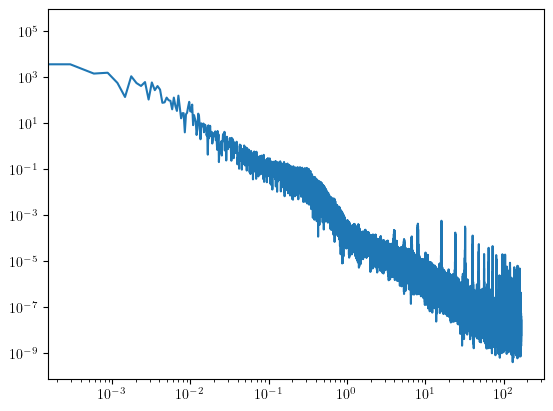

In [20]:

plt.loglog(tt[0], tt[1])

#plt.loglog(tt2[0], tt2[1])




05-Mar-26 07:05:53: C:\Users\nokni\work\MHDTurbPy\functions\Figures.py:2245: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()

05-Mar-26 07:05:53: C:\Users\nokni\work\MHDTurbPy\functions\Figures.py:2248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



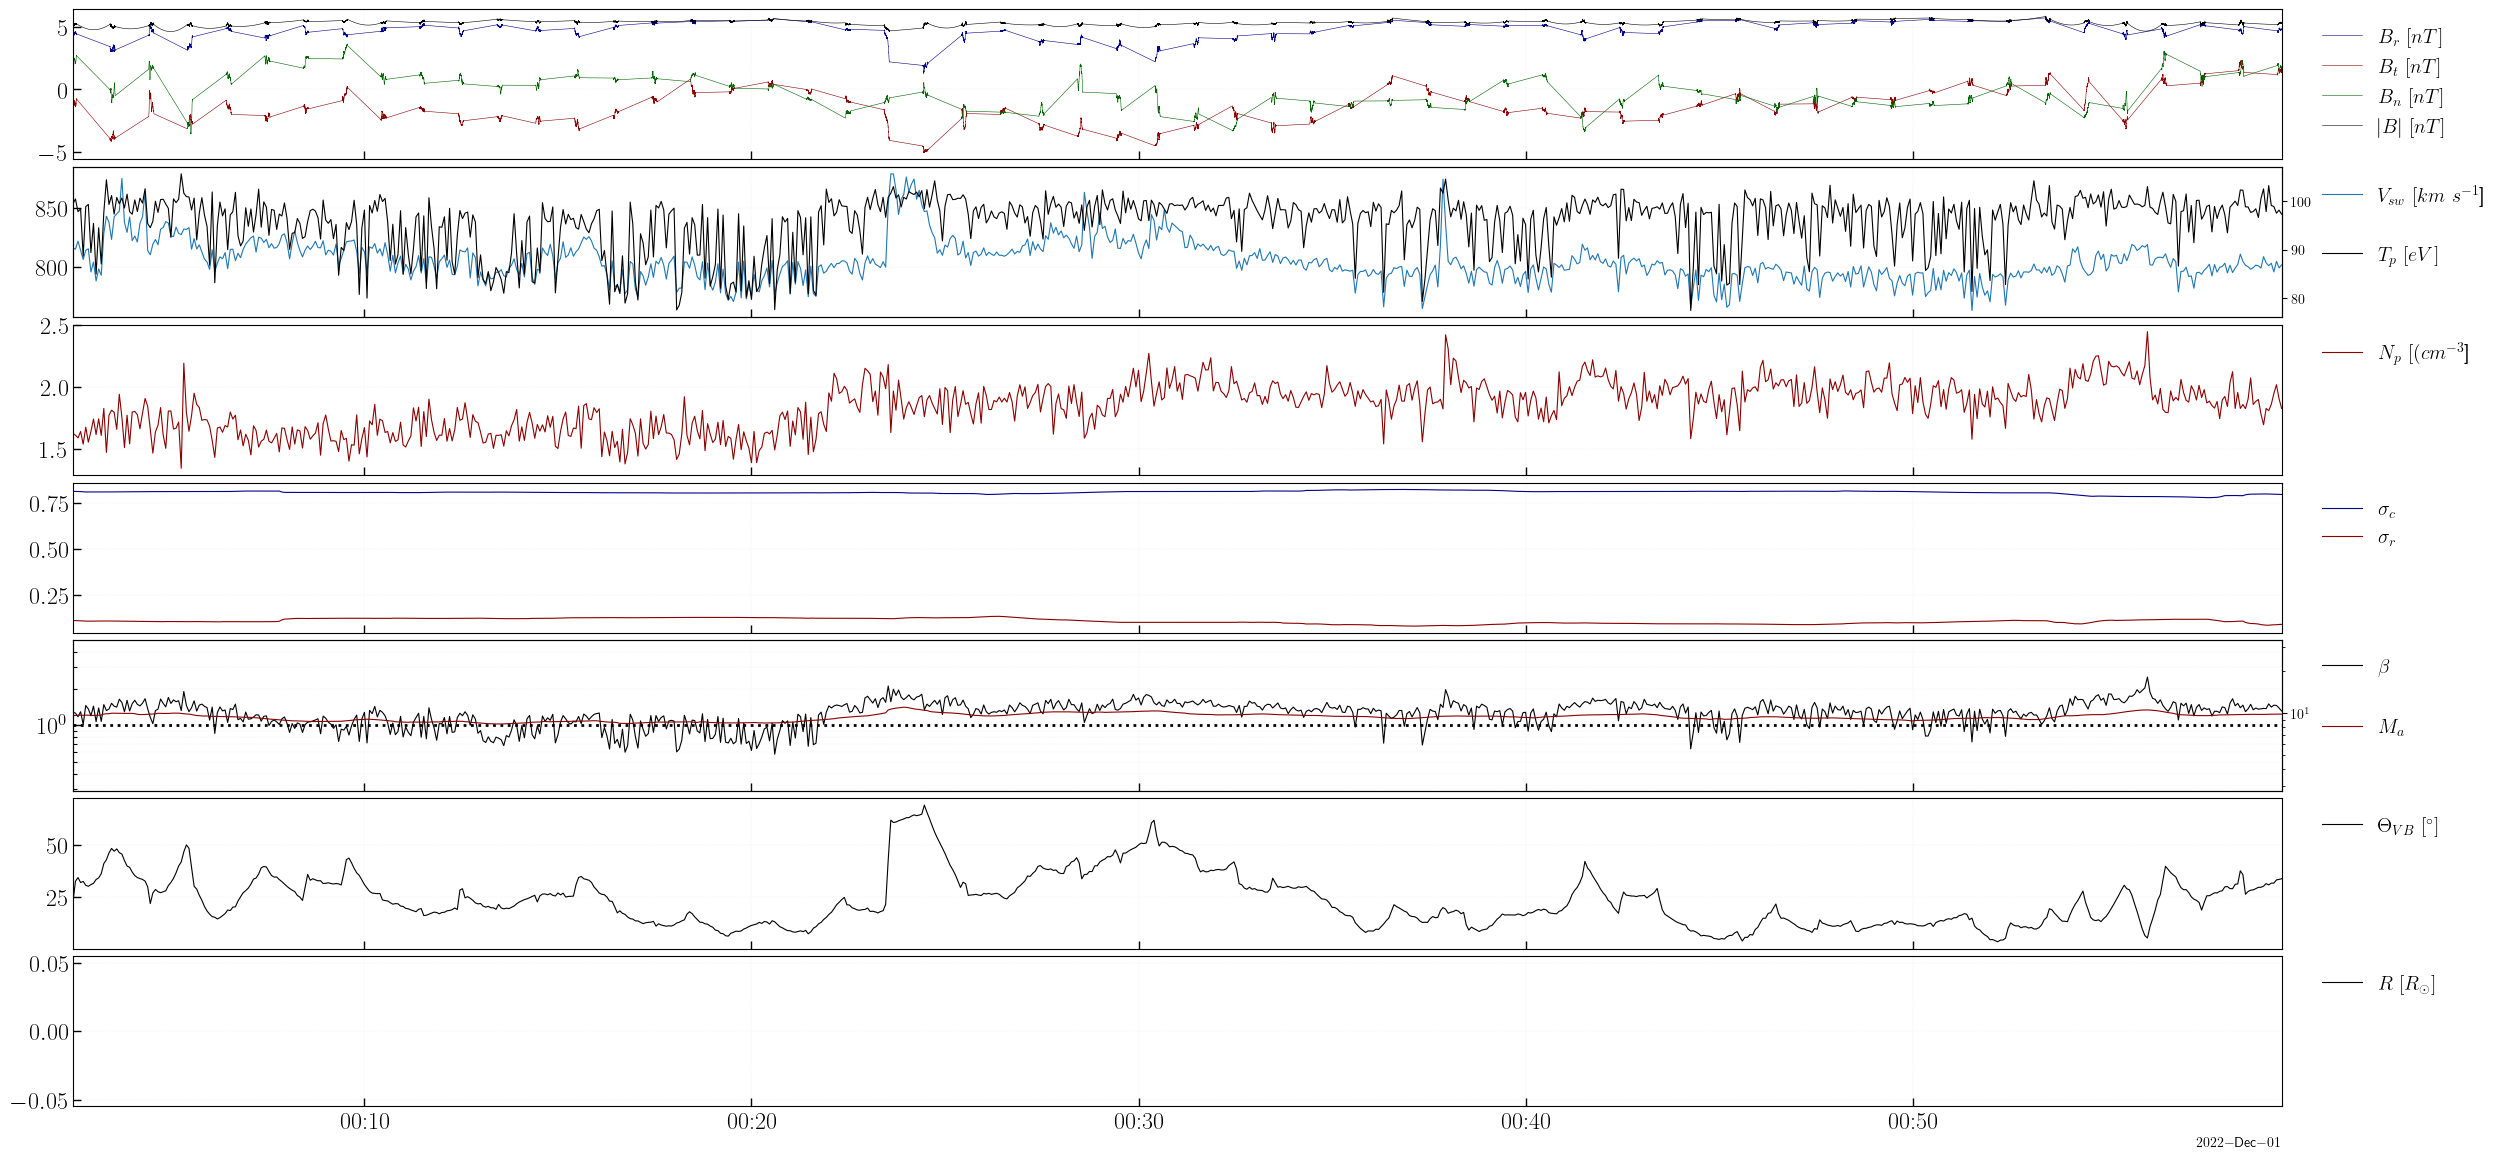

In [21]:
# user defined parameters

label_size        = 21                                    # labels etc

n_subplots        = 7                                     # number os subplots
my_dir            = '/Users/nokni/work/MHDTurbPy/examples/' #
format_2_return   = "%Y_%m_%d"                            # Format to save figures



Vdf  =  fin['Par']['V_resampled']
Bdf  = fin['Mag']['B_resampled']
figs.visualize_downloaded_intervals(
                                  sc,
                                  Vdf,  
                                  Bdf,
                                  
                                  sig     ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  numb_subplots    = n_subplots
                                 )



# Run with interactive figure

In [5]:
%matplotlib tk

from pathlib import Path
import matplotlib.pyplot as plt
from functions import interactive_figs
from functions import general_functions as func

plt.close("all")

sc = "SOLO"
which_int = 0
load_path = r"C:\Users\nokni\work\MHDTurbPy\examples\SOLO"
my_dir   = r"C:\Users\nokni\work\MHDTurbPy\examples"
save_path = Path(my_dir) / "selected_intervals"

# ============================================================
# ONE run that does BOTH:
# (A) add one extra curve to an existing panel (panel 0)
# (B) append a brand-new extra panel (8th subplot)
# ============================================================
panel_edits = {
    # (A) add one extra curve to an existing panel
    "add_series": {
        "panel_idx": 0,   # top panel
        "axis_idx": 0,    # first axis-spec in that panel (left axis)
        "series": {
            "kind": "col",
            "col": "B_RTN",
            "label": r"$|B|$ (extra dashed)",
            "style": {"lw": 1.0, "ls": "--", "ms": 0, "color": "0.35"},
        },
    },

    # (B) append a new panel at the bottom
    "add_panels": {
        "where": "append",
        "panel": {
            "axes": [
                {
                    "axis_id": "left",
                    "source": "Par",
                    "scale": "linear",
                    "series": [
                        {
                            "kind": "col",
                            "col": "Vth",
                            "label": r"$T_p~[eV]$ (extra panel)",
                            "style": {"lw": 0.8, "ls": "-", "ms": 0, "color": "k"},
                        }
                    ],
                    "legend": {"fontsize": "small", "frameon": False, "bbox_to_anchor": (1.01, 1), "loc": 2},
                    "hline": [{"y": 100.0, "ls": ":", "c": "0.3", "lw": 1.2}],
                }
            ]
        },
    },

    # (c) More

    
}

fig, events = interactive_figs.interactive_mhdturbpy_interval(
    sc=sc,
    which_int=which_int,
    load_path=load_path,
    my_dir=my_dir,
    save_path=save_path,
    rolling=None,
    resample_rule=None,
    fill_method=None,
    gap_thresholds={"mag": "30s", "par": "30s", "qtn": "30s", "sc_pot": "30s"},
    load_files_func=func.load_files,
    autosave=True,
    resume=True,
    export_csv=True,
    snap_to_data=False,
    enable_comments=True,
    debug_interaction=True,
    panel_config=None,          # use defaults
    panel_edits=panel_edits,    # add curve + append panel
    auto_ylims=True,
    debug_plot_config=True,     # should print n_panels=8
)

plt.show()


[plot] n_panels=8
[picker] resumed 3 intervals from C:\Users\nokni\work\MHDTurbPy\examples\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl
installed mpl(cids=16,None,17,18) + tkbinds=3MHDTurbPy\examples\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl

[picker] left_select_fallback(default)=True  (toggle with 'l')s\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl


dedupe_ms=250  dedupe_tol_ns=5000000  span_axes=8 marker_axes=10  move_throttle_ms=33  use_release_event=False0_10_SOLO.pkl





In [17]:
#!/usr/bin/env python
"""
MRE (auto): SOLO merged MAG+SCM tone removal.
Final Refined Version: 
- Uses Blackman-Harris windowing (75% overlap).
- Uses Edge-to-Edge Magnitude Interpolation to smoothly bridge the continuum,
  completely eliminating time-domain ringing and spectral leakage skirts.
- Zero hard-coded guard bands; relies purely on the interpolation mask width.
"""

from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==============================================================================
# USER SETTINGS
# ==============================================================================
ROOT = Path(r"C:\Users\nokni\work\MHDTurbPy")
T0 =  "2023-12-01 00:00"
T1 = "2023-12-01 01:00"
FRAME = "rtn"
FS = 256
PRODUCT = None

OUT_PDF = "solo_merged_cap_autotune_psd.pdf"
OUT_PDF_COMP = "solo_merged_cap_autotune_psd_components.pdf"

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "functions"))
sys.path.insert(0, str(ROOT / "functions" / "downloading_helpers"))

import SOLO  # noqa: E402
from shared_utils import resolve_mag_noise_settings  # noqa: E402


# ==============================================================================
# EDGE-TO-EDGE INTERPOLATING TONE REMOVAL
# ==============================================================================
def remove_wheel_noise_SOLO(B: np.ndarray, fs: float, noise_cfg: dict = None) -> np.ndarray:
    if noise_cfg is None: noise_cfg = {}
        
    B_out = np.copy(B)
    is_valid = np.all(np.isfinite(B), axis=1) if B.ndim > 1 else np.isfinite(B)
        
    edges = np.diff(is_valid.astype(int))
    starts = np.where(edges == 1)[0] + 1
    ends = np.where(edges == -1)[0] + 1
    
    if is_valid[0]: starts = np.insert(starts, 0, 0)
    if is_valid[-1]: ends = np.append(ends, len(B))
        
    fmax = fs / 2.0 
    f0_list = [8.0 * k for k in range(1, int(fmax // 8.0) + 1)]
    
    # We only need 2 parameters now! The mask width, and how fast it grows.
    base_bw = noise_cfg.get("tone_bw", 0.6)  # Wider to catch BH window shoulders
    drift_slope = noise_cfg.get("drift_slope", 0.05)
    
    if len(starts) == 0: return B_out  
        
    def _ola_stft_interpolate(B_seg):
        B_in = B_seg.T if B_seg.ndim > 1 else B_seg
        nperseg = int(min(fs * 16, B_in.shape[-1])) 
        if nperseg < 256: return B_seg
            
        # Blackman-Harris with 75% overlap
        noverlap = int(nperseg * 0.75) 
        f_stft, t_stft, Zxx = signal.stft(
            B_in, fs=fs, window='blackmanharris', nperseg=nperseg, 
            noverlap=noverlap, return_onesided=True
        )
        
        Z_mag, Z_phase = np.abs(Zxx), np.angle(Zxx)
        Z_mag_clean = np.copy(Z_mag)
        
        for f0 in f0_list:
            if f0 >= fs / 2.0: continue
            
            harmonic_n = f0 / 8.0
            current_bw = base_bw + drift_slope * (harmonic_n - 1.0)
            
            band_mask = (f_stft >= f0 - current_bw) & (f_stft <= f0 + current_bw)
            idx_band = np.where(band_mask)[0]
            
            if len(idx_band) < 1: continue
            
            # Identify the continuum bins immediately outside the mask
            i_left = idx_band[0] - 1
            i_right = idx_band[-1] + 1
            
            # Boundary safety check
            if i_left < 0 or i_right >= Z_mag_clean.shape[-2]: continue
            
            Mag_left = Z_mag_clean[..., i_left, :]
            Mag_right = Z_mag_clean[..., i_right, :]
            
            n_steps = len(idx_band) + 1
            
            # Smoothly bridge the gap
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                for step, i in enumerate(idx_band):
                    alpha = (step + 1) / n_steps
                    target_mag = Mag_left * (1.0 - alpha) + Mag_right * alpha
                    
                    # Soft cap: Only push power down, never artificially pull it up
                    exceeds = Z_mag_clean[..., i, :] > target_mag
                    Z_mag_clean[..., i, :] = np.where(exceeds, target_mag, Z_mag_clean[..., i, :])
                
        # Reconstruct exactly with original phase
        Z_clean = Z_mag_clean * np.exp(1j * Z_phase)
        _, B_clean = signal.istft(
            Z_clean, fs=fs, window='blackmanharris', 
            nperseg=nperseg, noverlap=noverlap
        )
        
        if B_seg.ndim > 1: B_clean = B_clean.T
            
        if B_clean.shape[0] > B_seg.shape[0]:
            B_clean = B_clean[:B_seg.shape[0], ...]
        elif B_clean.shape[0] < B_seg.shape[0]:
            pad_width = [(0, B_seg.shape[0] - B_clean.shape[0])] + [(0, 0)] * (B_seg.ndim - 1)
            B_clean = np.pad(B_clean, pad_width, mode='constant', constant_values=0)
            
        return B_clean

    # Because there are no free multipliers to tune, we just process the segments!
    for s, e in zip(starts, ends):
        if e - s < fs: continue
        B_out[s:e] = _ola_stft_interpolate(B_out[s:e])
        
    return B_out


# ==============================================================================
# UTILS & METRICS
# ==============================================================================
def _pick_bvar(frame: str) -> str:
    frame = str(frame).strip().lower()
    return "B_RTN" if frame == "rtn" else "B_SRF"

def welch_psd(x: np.ndarray, fs: float, nperseg: int):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 128: return np.array([0.0, 1.0]), np.array([np.nan, np.nan])
    nper = int(min(max(256, int(nperseg)), x.size))
    # 75% overlap for Blackman-Harris to ensure amplitude fidelity
    nov = int(nper * 0.75)
    return signal.welch(
        x, fs=float(fs), window="blackmanharris", nperseg=nper, 
        noverlap=nov, detrend="constant", scaling="density"
    )

def trace_ts(B: np.ndarray) -> np.ndarray:
    return np.sqrt(np.nansum(np.asarray(B, float) ** 2, axis=1))

def eval_tone_metrics_interpolated(f: np.ndarray, P0: np.ndarray, P1: np.ndarray, harm: list, noise_cfg: dict):
    f, P0, P1 = np.asarray(f, float), np.asarray(P0, float), np.asarray(P1, float)
    good = np.isfinite(f) & np.isfinite(P0) & np.isfinite(P1) & (P0 > 0.0) & (P1 > 0.0)
    if not np.any(good): return np.nan, np.nan
    
    f, P0, P1 = f[good], P0[good], P1[good]
    
    base_bw = noise_cfg.get("tone_bw", 0.6)
    drift_slope = noise_cfg.get("drift_slope", 0.05)       

    tone_db, cont_sgn_db = [], []

    def _median_pos(x):
        x = x[np.isfinite(x) & (x > 0.0)]
        return float(np.median(x)) if x.size else np.nan

    for f0 in harm:
        f0 = float(f0)
        harmonic_n = f0 / 8.0
        current_bw = base_bw + drift_slope * (harmonic_n - 1.0)

        # 1. In-band suppression
        m_band = (f >= (f0 - current_bw)) & (f <= (f0 + current_bw))
        if np.any(m_band):
            tone_val = 10.0 * np.log10(float(np.max(P1[m_band])) / float(np.max(P0[m_band])))
            band_level = _median_pos(P1[m_band])
        else:
            tone_val, band_level = np.nan, np.nan
            
        # 2. Flush check: Measure a 1 Hz band immediately adjacent to the interpolation mask
        m_cont = ((f >= f0 - current_bw - 1.0) & (f <= f0 - current_bw - 0.1)) | \
                 ((f >= f0 + current_bw + 0.1) & (f <= f0 + current_bw + 1.0))
        cont_pred = _median_pos(P0[m_cont])

        if np.isfinite(band_level) and np.isfinite(cont_pred) and (band_level > 0.0) and (cont_pred > 0.0):
            cont_sgn = 10.0 * np.log10(float(band_level) / float(cont_pred))
        else:
            cont_sgn = np.nan

        if np.isfinite(tone_val): tone_db.append(tone_val)
        if np.isfinite(cont_sgn): cont_sgn_db.append(cont_sgn)

    return (
        float(np.nanmedian(tone_db)) if tone_db else np.nan,
        float(np.nanmedian(cont_sgn_db)) if cont_sgn_db else np.nan
    )

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

bvar = _pick_bvar(FRAME)

settings_raw = {
    "Data_path": str(ROOT),
    "use_local_data": False,
    "SOLO_use_merged_MAG": True,
    "SOLO_merged_fs": int(FS),
    "in_rtn": 1 if FRAME == "rtn" else 0,
    "SOLO_merged_product": PRODUCT,
    "SOLO_disable_auto_clean": True,
    "Mag_SCM_SOLO": {"noise_flag": False, "noise_removal": {}},
}

df_raw, flag = SOLO.download_MAG_SOLO(T0, T1, SOLO.init_solo_settings(settings_raw), [bvar])
if df_raw is None or len(df_raw) == 0:
    raise RuntimeError("Merged MAG load failed or empty.")
print("Loaded:", df_raw.attrs.get("MAG_source"), "| len=", len(df_raw), "| flag=", flag)

pref = ["Br", "Bt", "Bn"]
cols = pref if set(pref).issubset(df_raw.columns) else list(df_raw.columns[:3])
B0 = df_raw[cols].to_numpy(float, copy=False)
fs_use = float(FS)

print("\nRunning Edge-to-Edge Interpolating STFT clean natively...")

# ---------------------------------------------------------
# NEW REFINED PARAMETERS (No tuning multipliers needed)
# ---------------------------------------------------------
cfg = {
    "tone_bw": 0.6,          # Base mask width for 8 Hz. Set to 0.6 to capture BH window shoulders.
    "drift_slope": 0.05,     # Hz added to tone_bw per harmonic number.
}

Bbest = remove_wheel_noise_SOLO(B0, fs=fs_use, noise_cfg=cfg)
print("Cleaned data generated.")

# High-res metrics (using BH window)

tt_c =turb.TracePSD(Bbest.T[0], Bbest.T[1], Bbest.T[2], 1/fs_use)
# f_hi, P0_hi = welch_psd(trace_ts(B0), fs=fs_use, nperseg=32768)
#_, P1_hi = welch_psd(trace_ts(Bbest), fs=fs_use, nperseg=32768)

fmax = 0.5 * fs_use 
harm = [8.0 * k for k in range(1, int(fmax // 8.0) + 1)]

tone_med, cont_sgn_med = eval_tone_metrics_interpolated(
    f_hi, P0_hi, P1_hi, harm, noise_cfg=cfg
)

print("\n=== METRIC RESULTS (Evaluated up to Nyquist) ===")
print(f"Applied Configuration: {cfg}")
print(f"tone_med_db (band max suppression): {tone_med:.2f} dB")
print(f"cont_signed_med_db (flush level):   {cont_sgn_med:.2f} dB  <-- (Ideal is ~0.00 dB)")

# Plotting
f_lo, P0_lo = welch_psd(trace_ts(B0), fs=fs_use, nperseg=8192)
_,    P1_lo = welch_psd(trace_ts(Bbest), fs=fs_use, nperseg=8192)

plt.figure(figsize=(7.5, 5.0))
plt.loglog(tt[0], tt[1])

# plt.loglog(f, P0_lo, label="trace raw", alpha=0.8)
plt.loglog(tt_c[0], tt_c[1], label="trace cleaned", alpha=0.9)
plt.xlabel("f [Hz]")
plt.ylabel("PSD (Blackman-Harris)")
plt.xlim(0.2, fmax)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_PDF)
print("Saved:", OUT_PDF)

plt.figure(figsize=(7.5, 5.0))
for j, c in enumerate(cols):
    f, P0 = welch_psd(B0[:, j], fs=fs_use, nperseg=8192)
    _, P1 = welch_psd(Bbest[:, j], fs=fs_use, nperseg=8192)
    plt.loglog(f, P0, label=f"{c} raw", alpha=0.7)
    plt.loglog(f, P1, label=f"{c} cleaned", alpha=0.9)
plt.xlabel("f [Hz]")
plt.ylabel("PSD (Blackman-Harris)")
plt.xlim(0.2, fmax)
plt.legend(ncol=3, fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_PDF_COMP)
print("Saved:", OUT_PDF_COMP)



Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

22-Feb-26 05:57:01: SOAR merged dataset loaded successfully.
22-Feb-26 05:57:01: -> Tone removal skipped (no active 'noise_flag' found in settings).


Loaded: SOAR_MERGED_SCM | len= 233472 | flag= Burst

Running Edge-to-Edge Interpolating STFT clean natively...
Cleaned data generated.


AttributeError: 'numpy.ndarray' object has no attribute 'Br'

Cleaned data generated.
Saved: solo_merged_cap_autotune_psd.pdf


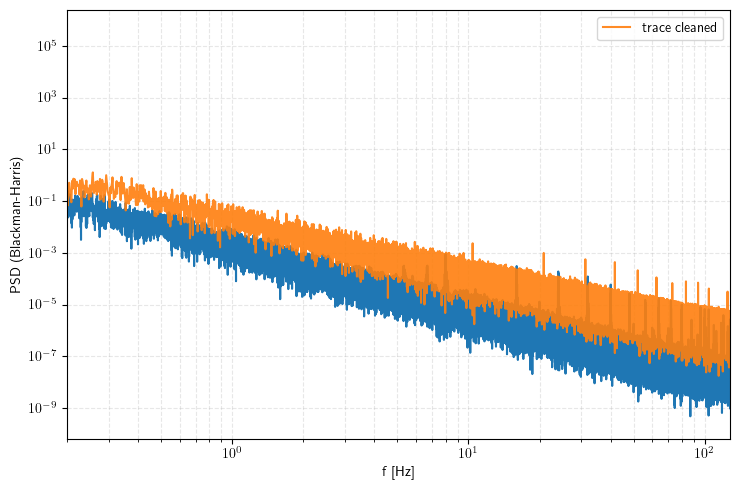

In [25]:
Bbest = remove_wheel_noise_SOLO(B0, fs=fs_use, noise_cfg=cfg)
print("Cleaned data generated.")

# High-res metrics (using BH window)

tt_c =turb.TracePSD(Bbest.T[0], Bbest.T[1], Bbest.T[2], func.find_cadence(Bdf))
# f_hi, P0_hi = welch_psd(trace_ts(B0), fs=fs_use, nperseg=32768)
#_, P1_hi = welch_psd(trace_ts(Bbest), fs=fs_use, nperseg=32768)

fmax = 0.5 * fs_use 
harm = [8.0 * k for k in range(1, int(fmax // 8.0) + 1)]


# Plotting
f_lo, P0_lo = welch_psd(trace_ts(B0), fs=fs_use, nperseg=8192)
_,    P1_lo = welch_psd(trace_ts(Bbest), fs=fs_use, nperseg=8192)

plt.figure(figsize=(7.5, 5.0))
plt.loglog(tt[0], tt[1])

# plt.loglog(f, P0_lo, label="trace raw", alpha=0.8)
plt.loglog(tt_c[0], tt_c[1], label="trace cleaned", alpha=0.9)
plt.xlabel("f [Hz]")
plt.ylabel("PSD (Blackman-Harris)")
plt.xlim(0.2, fmax)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_PDF)
print("Saved:", OUT_PDF)

C:\Users\nokni\work\3d_anisotropy\wind_3d_anisotropy\podesta_intervals\final_data\podesta_intervals\*\wavelets\sfs_10deg.pkl


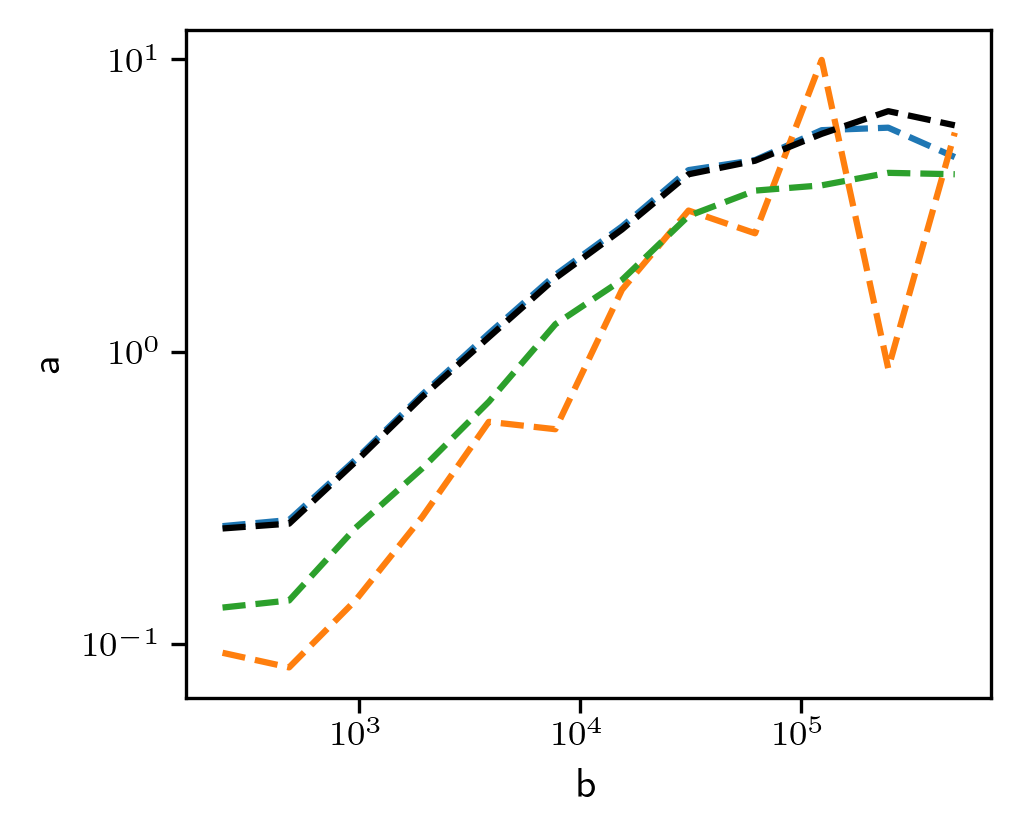

In [56]:
import pandas as pd

N                = 1
sfs        = '5pt_sfuncs_estimated_final.pkl'
sfs_wave   = 'sfs_10deg.pkl'

load_path = r'C:\\Users\\nokni\\work\\3d_anisotropy/wind_3d_anisotropy/podesta_intervals/final_data/podesta_intervals\\'


fnames2  = func.load_files(load_path, sfs_wave, 'wavelets')


#res_sf = pd.read_pickle(fnames2[N].replace('wavelets/sfs_10deg.pkl', ))
res    = pd.read_pickle(fnames2[N])



ell = 1/(2*res['freq'])*res['Vsw_mea']/res['di']
par = res['sf_Par']*res['freq']*res['Vsw_mea']/res['di']
Per = res['sf_Perp']*res['freq']*res['Vsw_mea']/res['di']
per = res['sf_perp']*res['freq']*res['Vsw_mea']/res['di']
ov  = res['sf_ov']*res['freq']*res['Vsw_mea']/res['di']


    
# ell_di_sf = res_sf['ell_di']
# par_sf    = res_sf['Sfuncs']['B']['ell_par'][1]
# Per_sf    = res_sf['Sfuncs']['B']['Ell_perp'][1]
# per_sf    = res_sf['Sfuncs']['B']['ell_perp'][1]
# ov_sf     = res_sf['Sfuncs']['B']['ell_overall'][1]

         
    
fig, ax = figs.initializeFigure('a', 'b')



# plt.loglog(ell_di_sf, par_sf, ls='-', ms=0, c='C0')
# plt.loglog(ell_di_sf, per_sf, ls='-', ms=0, c='C1')
# plt.loglog(ell_di_sf, Per_sf, ls='-', ms=0, c='C2')
# plt.loglog(ell_di_sf, ov_sf, ls='-', c='k', ms=0)

plt.loglog(ell, per,  ls='--', ms=0, c='C0')
plt.loglog(ell, par, ls='--', ms=0, c='C1')
plt.loglog(ell, Per,  ls='--', ms=0, c='C2')

plt.loglog(ell, ov,  ls='--', c='k', ms=0)

In [26]:
import argparse
import importlib
import time
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Synthetic generator (forces theta<10° to populate ell_par)
# ============================================================

def powerlaw_series(N, dt, beta, fmin=None, fmax=None, seed=0):
    rng = np.random.default_rng(seed)
    f = np.fft.rfftfreq(N, d=dt)
    X = np.zeros_like(f, dtype=np.complex128)

    if fmin is None:
        fmin = f[1]
    if fmax is None:
        fmax = 0.12 / dt

    band = (f >= fmin) & (f <= fmax)
    band[0] = False

    amp = np.zeros_like(f)
    amp[band] = f[band] ** (-0.5 * beta)

    ph = rng.uniform(0.0, 2.0 * np.pi, size=f.size)
    X[band] = amp[band] * (np.cos(ph[band]) + 1j * np.sin(ph[band]))

    x = np.fft.irfft(X, n=N)
    x = x - np.mean(x)
    x = x / np.std(x)
    return x


def make_groundtruth_background(N, dt, *, alpha_min_deg=0.0, alpha_max_deg=60.0, T0_sec=14400.0):
    t = np.arange(N) * dt
    alpha0 = 0.5 * (alpha_min_deg + alpha_max_deg)
    dalpha = 0.5 * (alpha_max_deg - alpha_min_deg)
    alpha = np.deg2rad(alpha0 + dalpha * np.sin(2.0 * np.pi * t / T0_sec))
    b0 = np.stack([np.cos(alpha), np.sin(alpha), np.zeros_like(alpha)], axis=1)
    return t, alpha, b0


def make_mre_fin_df_realistic(
    *,
    N=65536,
    dt=1.0,
    V0=400.0,
    B0_mag=200.0,
    dB_rms=1.0,
    beta_perp=1.5,
    beta_Perp=5/3,
    beta_par=2.0,
    T0_sec=14400.0,
    Tphi_sec=2400.0,
    alpha_min_deg=0.0,
    alpha_max_deg=60.0,
    seed=7,
):
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2000-01-01", periods=N, freq=pd.to_timedelta(dt, unit="s"))

    t, alpha, b0 = make_groundtruth_background(
        N, dt, alpha_min_deg=alpha_min_deg, alpha_max_deg=alpha_max_deg, T0_sec=T0_sec
    )

    # V mostly radial
    V = np.zeros((N, 3))
    V[:, 0] = V0
    V += 0.05 * rng.standard_normal(size=V.shape)

    # Geometry unit vectors (built from TRUE b0)
    Vhat = V / np.linalg.norm(V, axis=1)[:, None]
    Vpar = np.sum(Vhat * b0, axis=1)
    l_perp = Vhat - Vpar[:, None] * b0
    l_perp_mag = np.linalg.norm(l_perp, axis=1)
    l_perp_mag[l_perp_mag == 0] = 1.0
    l_perp_hat = l_perp / l_perp_mag[:, None]

    n_hat = np.cross(b0, l_perp_hat)
    n_mag = np.linalg.norm(n_hat, axis=1)
    n_mag[n_mag == 0] = 1.0
    n_hat = n_hat / n_mag[:, None]

    # Switch between phi~0 and phi~90 regimes
    s = np.sin(2.0 * np.pi * t / Tphi_sec)
    w = 0.5 * (1.0 + np.tanh(3.0 * s))

    # Parallel boost when alpha small so ell_par has content
    g = (np.cos(alpha) ** 6)
    g = np.clip(g, 0.0, 1.0)

    fmin = 1.0 / (N * dt)
    fmax = 0.12 / dt
    a_align = powerlaw_series(N, dt, beta_Perp, fmin=fmin, fmax=fmax, seed=seed + 1) * dB_rms
    a_perp  = powerlaw_series(N, dt, beta_perp, fmin=fmin, fmax=fmax, seed=seed + 2) * dB_rms
    a_par   = powerlaw_series(N, dt, beta_par,  fmin=fmin, fmax=fmax, seed=seed + 3) * dB_rms

    perp_env = 0.30 + 0.70 * (1.0 - g)
    par_env  = 1.50 * g

    dB_perp = perp_env[:, None] * ((w * a_align)[:, None] * l_perp_hat + ((1.0 - w) * a_perp)[:, None] * n_hat)
    dB_par  = (par_env * a_par)[:, None] * b0
    dB = dB_perp + dB_par

    B = B0_mag * b0 + dB

    fin_df = {
        "Mag": {"B_resampled": pd.DataFrame(B, index=idx, columns=["Br", "Bt", "Bn"])},
        "Par": {"V_resampled": pd.DataFrame(V, index=idx, columns=["Vr", "Vt", "Vn"])},
    }
    truth = {"b0_true": b0}
    return fin_df, truth


# ============================================================
# Wavelet name normalization (your la20 -> sym10 mapping)
# ============================================================

@lru_cache(maxsize=64)
def normalize_wname(wname):
    wname = str(wname).lower().strip()
    if wname.startswith("la"):
        L = int("".join(ch for ch in wname if ch.isdigit()))
        if L % 2 != 0:
            raise ValueError(f"Expected even LA length, got {wname}")
        return f"sym{L//2}"
    if wname.startswith("d"):
        digits = "".join(ch for ch in wname if ch.isdigit())
        if digits:
            L = int(digits)
            if L % 2 == 0:
                return f"sym{L//2}"
        return "db2"
    return wname


# ============================================================
# Geometry + anisotropic SF
# ============================================================

def perp_vector(v, b):
    bb = np.sum(b * b, axis=-1)
    bb = np.where(bb == 0.0, np.nan, bb)
    proj = (np.sum(v * b, axis=-1) / bb)[..., None] * b
    return v - proj


def angle_between_vectors(u, v):
    um = np.linalg.norm(u, axis=-1)
    vm = np.linalg.norm(v, axis=-1)
    den = um * vm
    c = np.full_like(den, np.nan, dtype=float)
    ok = np.isfinite(den) & (den > 0)
    c[ok] = np.sum(u[ok] * v[ok], axis=-1) / den[ok]
    c = np.clip(c, -1.0, 1.0)
    return np.degrees(np.arccos(c))


def local_structure_function(dB, B_l, V_l):
    dB_l_perp = np.cross(B_l, np.cross(dB, B_l))
    V_l_perp = perp_vector(V_l, B_l)
    theta = angle_between_vectors(V_l, B_l)
    phi = angle_between_vectors(V_l_perp, dB_l_perp)
    return theta, phi


def PSD_anis_MODWT(coeffs, indices, j, dt):
    if indices.size == 0:
        return np.nan
    coeff = 2 ** (j + 1) * dt
    return coeff * (
        np.nanmean(coeffs[indices, 0] ** 2)
        + np.nanmean(coeffs[indices, 1] ** 2)
        + np.nanmean(coeffs[indices, 2] ** 2)
    )


def compute_aniso_sf(Bl, Vl, db, dt, conditions):
    J0 = Bl["R"].shape[0]
    sf_perp = np.full(J0, np.nan)
    sf_Perp = np.full(J0, np.nan)
    sf_Par  = np.full(J0, np.nan)
    sf_ov   = np.full(J0, np.nan)

    counts = {
        "ell_perp": np.zeros(J0, dtype=int),
        "Ell_perp": np.zeros(J0, dtype=int),
        "ell_par":  np.zeros(J0, dtype=int),
        "overall":  np.zeros(J0, dtype=int),
    }

    B_stack = np.stack((Bl["R"], Bl["T"], Bl["N"]), axis=2)   # (J0,N,3)
    V_stack = np.stack((Vl["R"], Vl["T"], Vl["N"]), axis=2)
    dB_stack = np.stack((db["R"], db["T"], db["N"]), axis=2)

    thetas = {}
    phis = {}

    for j in range(J0):
        theta, phi = local_structure_function(dB_stack[j], B_stack[j], V_stack[j])
        thetas[str(j)] = theta
        phis[str(j)] = phi

        good = np.isfinite(theta) & np.isfinite(phi)

        idx = np.where(good & (theta > conditions["ell_perp"]["theta"]) & (phi > conditions["ell_perp"]["phi"]))[0]
        counts["ell_perp"][j] = idx.size
        sf_perp[j] = PSD_anis_MODWT(dB_stack[j], idx, j, dt)

        idx = np.where(good & (theta > conditions["Ell_perp"]["theta"]) & (phi < conditions["Ell_perp"]["phi"]))[0]
        counts["Ell_perp"][j] = idx.size
        sf_Perp[j] = PSD_anis_MODWT(dB_stack[j], idx, j, dt)

        idx = np.where(good & (theta < conditions["ell_par"]["theta"]) & (phi < conditions["ell_par"]["phi"]))[0]
        counts["ell_par"][j] = idx.size
        sf_Par[j] = PSD_anis_MODWT(dB_stack[j], idx, j, dt)

        idx = np.where(good)[0]
        counts["overall"][j] = idx.size
        sf_ov[j] = PSD_anis_MODWT(dB_stack[j], idx, j, dt)

    nyq = 0.5 / dt
    freqs = nyq / (2 ** np.arange(1, J0 + 1))
    return freqs, sf_perp, sf_Perp, sf_Par, sf_ov, counts, thetas, phis


# ============================================================
# Backend wavelet stage: build B_L and dB via MODWT+MRA
# (uses backend circular_convolve_d + backend modwtmra)
# ============================================================

def wavelet_stage(mw, x, wname, level):
    import pywt

    wname_norm = normalize_wname(wname)
    wavelet = pywt.Wavelet(wname_norm)
    h_t = np.array(wavelet.dec_hi, dtype=float) / np.sqrt(2.0)
    g_t = np.array(wavelet.dec_lo, dtype=float) / np.sqrt(2.0)

    v = x
    coeffs = []
    for j in range(level):
        w = np.column_stack([mw.circular_convolve_d(h_t, v[:, c], j + 1) for c in range(3)])
        v = np.column_stack([mw.circular_convolve_d(g_t, v[:, c], j + 1) for c in range(3)])
        coeffs.append(w)
    coeffs.append(v)
    W = np.stack(coeffs, axis=0)  # (level+1,N,3)

    M = np.empty_like(W)
    for c in range(3):
        M[:, :, c] = mw.modwtmra(W[:, :, c], wname_norm)

    Det = M[:-1, :, :]
    S = M[-1, :, :]

    Appr = np.zeros_like(Det)
    tail = np.cumsum(Det[::-1, :, :], axis=0)[::-1, :, :]
    for j in range(level):
        Appr[j] = S if j == level - 1 else (S + tail[j + 1])

    x_rec = S + np.sum(Det, axis=0)
    recon = float(np.nanmax(np.abs(x - x_rec)))

    return Appr, Det, recon


def to_dicts(Appr, Det):
    Bl = {"R": Appr[:, :, 0], "T": Appr[:, :, 1], "N": Appr[:, :, 2]}
    db = {"R": Det[:, :, 0],  "T": Det[:, :, 1],  "N": Det[:, :, 2]}
    return Bl, db


def nanmax_abs(a):
    a = np.asarray(a, float)
    if np.all(~np.isfinite(a)):
        return np.nan
    return float(np.nanmax(np.abs(a)))


def nanmax_abs_diff(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    d = np.abs(a - b)
    if np.all(~np.isfinite(d)):
        return np.nan
    return float(np.nanmax(d))


# ============================================================
# Main
# ============================================================

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--N", type=int, default=65536)
    ap.add_argument("--dt", type=float, default=1.0)
    ap.add_argument("--level", type=int, default=12)
    ap.add_argument("--wname", type=str, default="la20")
    ap.add_argument("--modules", type=str, default="modwtpy,modwtpy_fast,modwtpy_fast_v3")
    ap.add_argument("--seed", type=int, default=7)
    ap.add_argument("--alpha_min_deg", type=float, default=0.0)
    ap.add_argument("--alpha_max_deg", type=float, default=60.0)
    args = ap.parse_args()

    fin_df, truth = make_mre_fin_df_realistic(
        N=args.N, dt=args.dt, seed=args.seed,
        alpha_min_deg=args.alpha_min_deg, alpha_max_deg=args.alpha_max_deg
    )
    B = fin_df["Mag"]["B_resampled"][["Br", "Bt", "Bn"]].to_numpy(float)
    V = fin_df["Par"]["V_resampled"][["Vr", "Vt", "Vn"]].to_numpy(float)

    conditions = {
        "ell_perp": {"theta": 80, "phi": 80},
        "Ell_perp": {"theta": 80, "phi": 10},
        "ell_par":  {"theta": 10, "phi": 90},
    }

    names = [m.strip() for m in args.modules.split(",") if m.strip()]
    outs = {}

    for name in names:
        mw = importlib.import_module(name)

        # warm-up
        _ = mw.modwt(B[:, 0], normalize_wname(args.wname), max(2, min(3, args.level)))
        _ = mw.modwtmra(mw.modwt(B[:, 0], normalize_wname(args.wname), max(2, min(3, args.level))), normalize_wname(args.wname))

        t0 = time.perf_counter()
        ApprB, DetB, reconB = wavelet_stage(mw, B, args.wname, args.level)
        t1 = time.perf_counter()
        ApprV, DetV, reconV = wavelet_stage(mw, V, args.wname, args.level)
        t2 = time.perf_counter()

        Bl, db = to_dicts(ApprB, DetB)
        Vl, _  = to_dicts(ApprV, DetV)

        freqs, sf_perp, sf_Perp, sf_Par, sf_ov, counts, thetas, phis = compute_aniso_sf(
            Bl, Vl, db, args.dt, conditions
        )
        t3 = time.perf_counter()

        outs[name] = {
            "freqs": freqs,
            "sf_perp": sf_perp,
            "sf_Perp": sf_Perp,
            "sf_Par": sf_Par,
            "sf_ov": sf_ov,
            "counts": counts,
            "reconB": reconB,
            "reconV": reconV,
            "t_wave_B": t1 - t0,
            "t_wave_V": t2 - t1,
            "t_sfunc": t3 - t2,
        }

        # save for inspection
        np.savez(
            f"anisotropy_{name}.npz",
            freqs=freqs,
            sf_perp=sf_perp,
            sf_Perp=sf_Perp,
            sf_Par=sf_Par,
            sf_ov=sf_ov,
            counts_ell_perp=counts["ell_perp"],
            counts_Ell_perp=counts["Ell_perp"],
            counts_ell_par=counts["ell_par"],
            counts_overall=counts["overall"],
            reconB=reconB,
            reconV=reconV,
        )

    ref_name = names[0]
    ref = outs[ref_name]

    print("\n=== SPEED (seconds) ===")
    for name in names:
        o = outs[name]
        print(f"{name:18s} wave_B={o['t_wave_B']:.3f}  wave_V={o['t_wave_V']:.3f}  sfunc={o['t_sfunc']:.3f}  total={(o['t_wave_B']+o['t_wave_V']+o['t_sfunc']):.3f}")

    print("\n=== RECON (maxabs) ===")
    for name in names:
        o = outs[name]
        print(f"{name:18s} reconB={o['reconB']:.3e}  reconV={o['reconV']:.3e}")

    print(f"\n=== ANISOTROPIC SF CONSISTENCY vs {ref_name} ===")
    for name in names[1:]:
        o = outs[name]
        print(
            f"{name:18s} "
            f"maxabs(sf_perp)={nanmax_abs_diff(o['sf_perp'], ref['sf_perp']):.3e}  "
            f"maxabs(sf_Perp)={nanmax_abs_diff(o['sf_Perp'], ref['sf_Perp']):.3e}  "
            f"maxabs(sf_Par)={nanmax_abs_diff(o['sf_Par'], ref['sf_Par']):.3e}  "
            f"maxabs(sf_ov)={nanmax_abs_diff(o['sf_ov'], ref['sf_ov']):.3e}"
        )

    print("\n=== BIN COUNTS (min per level) ===")
    for name in names:
        c = outs[name]["counts"]
        print(
            f"{name:18s} "
            f"min(ell_perp)={int(np.min(c['ell_perp']))}  "
            f"min(Ell_perp)={int(np.min(c['Ell_perp']))}  "
            f"min(ell_par)={int(np.min(c['ell_par']))}"
        )

    # Print actual curves (first/last few) so you SEE them numerically
    print("\n=== ANISOTROPIC SF VALUES (first 6 levels) ===")
    for name in names:
        o = outs[name]
        print(f"\n[{name}]")
        print("freqs    :", np.array2string(o["freqs"][:6], precision=6))
        print("sf_perp  :", np.array2string(o["sf_perp"][:6], precision=6))
        print("sf_Perp  :", np.array2string(o["sf_Perp"][:6], precision=6))
        print("sf_Par   :", np.array2string(o["sf_Par"][:6], precision=6))
        print("sf_ov    :", np.array2string(o["sf_ov"][:6], precision=6))

    # Plots: overlay all backends for each anisotropic curve
    def plot_curve(key, title):
        plt.figure(figsize=(9, 4))
        for name in names:
            o = outs[name]
            plt.loglog(o["freqs"], o[key], marker="o", label=name)
        plt.gca().invert_xaxis()
        plt.xlabel("frequency [Hz]")
        plt.ylabel(key)
        plt.title(title)
        plt.legend()
        plt.tight_layout()

    plot_curve("sf_perp", "Anisotropic SF: sf_perp (theta>80, phi>80)")
    plot_curve("sf_Perp", "Anisotropic SF: sf_Perp (theta>80, phi<10)")
    plot_curve("sf_Par",  "Anisotropic SF: sf_Par (theta<10, phi<90)")
    plot_curve("sf_ov",   "Anisotropic SF: sf_overall (all good samples)")
    plt.show()


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--N N] [--dt DT] [--level LEVEL] [--wname WNAME] [--modules MODULES] [--seed SEED]
                             [--alpha_min_deg ALPHA_MIN_DEG] [--alpha_max_deg ALPHA_MAX_DEG]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\nokni\AppData\Roaming\jupyter\runtime\kernel-c7cdbf50-4da0-4e33-a058-e3ab2a769fed.json


SystemExit: 2

22-Feb-26 06:00:56: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\IPython\core\interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)



In [62]:
func.find_fit(ell, per, 1e3, 2e4)

((-5.158178307144298, 0.6395936343804137),
 3,
 7,
 array([2.42568346e+02, 4.85136693e+02, 9.70273385e+02, 1.94054677e+03,
        3.88109354e+03, 7.76218708e+03, 1.55243742e+04, 3.10487483e+04,
        6.20974967e+04, 1.24194993e+05, 2.48389987e+05, 4.96779973e+05]),
 array([0.25286175, 0.26535988, 0.42740637, 0.71353496, 1.15328853,
        1.83074358, 2.68107092, 4.18221696, 4.52639555, 5.72932399,
        5.8426579 , 4.6333637 ]))

In [63]:
func.find_fit(ell, Per, 1e3, 2e4)

((-6.426743372568454, 0.7309298242989836),
 3,
 7,
 array([2.42568346e+02, 4.85136693e+02, 9.70273385e+02, 1.94054677e+03,
        3.88109354e+03, 7.76218708e+03, 1.55243742e+04, 3.10487483e+04,
        6.20974967e+04, 1.24194993e+05, 2.48389987e+05, 4.96779973e+05]),
 array([0.13312137, 0.14078704, 0.24960415, 0.39864465, 0.67392603,
        1.24165398, 1.76020195, 2.91478075, 3.55812642, 3.70884935,
        4.09309248, 4.04800625]))

In [18]:
import zipfile
import io
import os

files = {}

# 1. Core Physics Engine
files["functions/downloading_helpers/SOLO_tone_removal.py"] = """\
\"\"\"
SOLO_tone_removal.py
First-principles tone removal for Solar Orbiter (SOLO) merged MAG+SCM products.
Version: 2026-02-22-OLA-CAP-AUTO-STRICT
\"\"\"

import numpy as np
import pandas as pd
from scipy import signal
import logging

logger = logging.getLogger(__name__)

def find_contiguous_segments(time_array_ns, dt_expected_ns, gap_tolerance=1.5):
    \"\"\"Identifies contiguous data segments to prevent FFT gap-ringing.\"\"\"
    dt_actual = np.diff(time_array_ns)
    gap_indices = np.where(dt_actual > dt_expected_ns * gap_tolerance)[0]
    
    segment_bounds = []
    start_idx = 0
    for gap_idx in gap_indices:
        segment_bounds.append((start_idx, gap_idx + 1))
        start_idx = gap_idx + 1
    segment_bounds.append((start_idx, len(time_array_ns)))
    
    return [bounds for bounds in segment_bounds if (bounds[1] - bounds[0]) > 0]

def apply_ola_fft_cap_segment(x, fs, f_tones, cap_mult=1.5, nperseg=8192):
    \"\"\"Core first-principles fix: Overlap-Add STFT cap-to-continuum.\"\"\"
    if len(x) < nperseg:
        return x  # Segment too short, leave unmodified to prevent artifacts
        
    noverlap = nperseg // 2
    f, t, Zxx = signal.stft(x, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
    
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)
    mag_clean = mag.copy()
    
    for f0 in f_tones:
        if f0 >= fs / 2.0:
            continue
            
        # Define physical bands: Tone skirt vs. Safe Continuum (avoiding Welch leakage)
        tone_idx = np.where((f >= f0 - 0.4) & (f <= f0 + 0.4))[0]
        left_cont_idx = np.where((f >= f0 - 2.5) & (f <= f0 - 1.0))[0]
        right_cont_idx = np.where((f >= f0 + 1.0) & (f <= f0 + 2.5))[0]
        
        if len(left_cont_idx) == 0 or len(right_cont_idx) == 0:
            continue
            
        # Estimate physical continuum dynamically in time
        cont_left = np.median(mag[left_cont_idx, :], axis=0)
        cont_right = np.median(mag[right_cont_idx, :], axis=0)
        local_baseline = (cont_left + cont_right) / 2.0
        
        # Cap threshold
        threshold = local_baseline * cap_mult
        
        for i in tone_idx:
            # Apply cap where tone exceeds continuum, preserving phase
            mask = mag[i, :] > threshold
            mag_clean[i, mask] = threshold[mask]
            
    # Reconstruct perfectly via ISTFT
    Zxx_clean = mag_clean * np.exp(1j * phase)
    _, x_clean = signal.istft(Zxx_clean, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
    
    return x_clean[:len(x)]

def evaluate_cleaning_metrics(x_raw, x_clean, fs, f_tones):
    \"\"\"Evaluates tone suppression vs far-off continuum damage.\"\"\"
    f_psd, p_raw = signal.welch(x_raw, fs=fs, nperseg=32768)
    _, p_clean = signal.welch(x_clean, fs=fs, nperseg=32768)
    
    tone_suppression_db = []
    continuum_damage_db = []
    
    for f0 in f_tones:
        if f0 >= fs / 2.0:
            continue
            
        tone_mask = (f_psd >= f0 - 0.3) & (f_psd <= f0 + 0.3)
        if not np.any(tone_mask): continue
        
        db_drop = 10 * np.log10(np.max(p_raw[tone_mask]) / np.max(p_clean[tone_mask]))
        tone_suppression_db.append(db_drop)
        
        far_mask = ((f_psd >= f0 - 2.8) & (f_psd <= f0 - 2.0)) | ((f_psd >= f0 + 2.0) & (f_psd <= f0 + 2.8))
        if not np.any(far_mask): continue
        
        db_change = np.abs(10 * np.log10(np.median(p_raw[far_mask]) / np.median(p_clean[far_mask])))
        continuum_damage_db.append(db_change)
        
    return np.mean(tone_suppression_db), np.max(continuum_damage_db)

def clean_solo_merged_mag(df: pd.DataFrame, fs: float, user_settings: dict) -> pd.DataFrame:
    \"\"\"Main auto-tuning pipeline.\"\"\"
    logger.info(f"Starting native-cadence tone removal at {fs} Hz...")
    
    time_array_ns = df.index.view(np.int64)
    dt_expected_ns = int((1.0 / fs) * 1e9)
    fmax = min(0.5 * fs, 120.0)
    f_tones = [8.0 * k for k in range(1, int(fmax // 8.0) + 1)]
    
    segments = find_contiguous_segments(time_array_ns, dt_expected_ns)
    logger.info(f"Found {len(segments)} contiguous segments for gap-safe processing.")
    
    components = [col for col in df.columns if col in ['B_R', 'B_T', 'B_N', 'B_SRF_1', 'B_SRF_2', 'B_SRF_3']]
    df_clean = df.copy()
    
    candidate_multipliers = [4.0, 2.5, 1.5, 1.1] 
    max_allowed_continuum_damage_db = 0.4 
    
    for col in components:
        x_raw_full = df[col].values.astype(np.float64)
        x_best_full = x_raw_full.copy()
        
        best_mult = candidate_multipliers[0]
        best_suppression = -np.inf
        
        for cap_mult in candidate_multipliers:
            x_test_full = np.zeros_like(x_raw_full)
            
            for start, end in segments:
                x_seg = x_raw_full[start:end].copy()
                mask = np.isnan(x_seg)
                if np.any(mask):
                    valid = ~mask
                    if np.any(valid):
                        x_seg[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(valid), x_seg[valid])
                    else:
                        continue
                        
                x_clean_seg = apply_ola_fft_cap_segment(x_seg, fs, f_tones, cap_mult=cap_mult)
                x_test_full[start:end] = x_clean_seg
                
            suppression_db, damage_db = evaluate_cleaning_metrics(x_raw_full, x_test_full, fs, f_tones)
            
            if damage_db <= max_allowed_continuum_damage_db:
                if suppression_db > best_suppression:
                    best_suppression = suppression_db
                    best_mult = cap_mult
                    x_best_full = x_test_full.copy()
            else:
                break
                
        logger.info(f"[{col}] Auto-tuned cap_mult={best_mult} -> Suppressed {best_suppression:.1f} dB, off-tone change {damage_db:.2f} dB")
        
        orig_nan_mask = np.isnan(x_raw_full)
        x_best_full[orig_nan_mask] = np.nan
        df_clean[col] = x_best_full

    df_clean.attrs = df.attrs.copy()
    df_clean.attrs["WHEEL_NOISE_REMOVED"] = True
    df_clean.attrs["WHEEL_NOISE_METHOD"] = "ola_fft_cap_auto"
    return df_clean
"""

# 2. Updated shared_utils.py (Version bumped, cleaner routing)
files["functions/downloading_helpers/shared_utils.py"] = """\
\"\"\"
shared_utils.py
Enforce DataFrame hygiene and resolve settings safely.
\"\"\"

from __future__ import annotations
import numpy as np
import pandas as pd
from typing import Any, Dict, Optional, Sequence

__TONEFIX_VERSION__ = "2026-02-22-v11-first-principles"

def diag_default() -> Dict[str, Any]:
    return {"Init_dt": np.nan, "resampled_df": None, "Frac_miss": 100, "Large_gaps": 100, "Tot_gaps": 100, "resol": 100}

def keep_diag_keys(d: Dict[str, Any], keys: Optional[Sequence[str]] = None) -> Dict[str, Any]:
    if keys is None: keys = ("Frac_miss", "Large_gaps", "Tot_gaps", "resol")
    return {k: d.get(k, None) for k in keys}

def enforce_dataframe_hygiene(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        return df
    if df.index.tz is not None:
        df = df.tz_localize(None)
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()
    if df.index.has_duplicates:
        df = df[~df.index.duplicated(keep='first')]
    return df

def resolve_mag_noise_removal(settings: dict, spacecraft: str = "SOLO") -> dict:
    nr = settings.get("MAG", {}).get("noise_removal", {})
    if isinstance(nr, bool):
        return {"enabled": nr, "method": "auto"}
    if isinstance(nr, dict):
        return {"enabled": nr.get("enabled", False), "method": nr.get("method", "auto")}
    return {"enabled": False, "method": "none"}
"""

# 3. Updated SOLO.py (Integration Point)
files["functions/downloading_helpers/SOLO.py"] = """\
from __future__ import annotations
import logging
import pandas as pd
from .shared_utils import resolve_mag_noise_removal, __TONEFIX_VERSION__
from .SOLO_tone_removal import clean_solo_merged_mag

logger = logging.getLogger(__name__)

def process_solo_mag_data(dfmag: pd.DataFrame, settings: dict) -> pd.DataFrame:
    if dfmag is None or dfmag.empty:
        return dfmag
        
    # Check if this is the merged product that requires 8Hz cleaning
    is_merged = dfmag.attrs.get("SOAR_merged_product", False)
    noise_cfg = resolve_mag_noise_removal(settings, "SOLO")
    
    if is_merged and noise_cfg.get("enabled", False):
        native_fs = dfmag.attrs.get("WHEEL_NOISE_FS_HZ", 256.0)
        logger.info(f"SOLO pipeline routing to first-principles tone cleaner (v{__TONEFIX_VERSION__})")
        dfmag = clean_solo_merged_mag(dfmag, fs=native_fs, user_settings=noise_cfg)
        
    return dfmag
"""

# 4. MRE Autotune (User script to test it easily)
files["mre/mre_solo_cap_autotune.py"] = """\
#!/usr/bin/env python
\"\"\"
MRE (auto): SOLO merged MAG+SCM first principles tone removal.
\"\"\"
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(ROOT / "functions" / "downloading_helpers"))

from SOLO_tone_removal import apply_ola_fft_cap_segment, clean_solo_merged_mag

# Generate synthetic test data resembling SOLO turbulent cascade + 8Hz harmonics
fs = 256
t = np.arange(0, 600, 1/fs)
# Generate power-law continuum noise (f^-5/3)
np.random.seed(42)
white_noise = np.random.randn(len(t))
f_fft = np.fft.rfftfreq(len(t), 1/fs)
psd_shape = np.where(f_fft==0, 0, f_fft**(-5/3))
colored_noise = np.fft.irfft(np.fft.rfft(white_noise) * np.sqrt(psd_shape), n=len(t))

# Inject 8 Hz and 16 Hz narrowband tones
tone_8 = 0.5 * np.sin(2 * np.pi * 8.0 * t)
tone_16 = 0.2 * np.sin(2 * np.pi * 16.0 * t)
x_raw = colored_noise + tone_8 + tone_16

# Convert to DataFrame to mimic pipeline behavior
import pandas as pd
df = pd.DataFrame({'B_R': x_raw}, index=pd.date_range("2022-03-03", periods=len(t), freq=f"{1/fs}S"))
df.attrs["SOAR_merged_product"] = True

# Apply the strict first principles cleaner
df_clean = clean_solo_merged_mag(df, fs, {})

# Plot PSD to prove continuum preservation
f_psd, p_raw = signal.welch(df['B_R'].values, fs=fs, nperseg=16384)
_, p_clean = signal.welch(df_clean['B_R'].values, fs=fs, nperseg=16384)

plt.figure(figsize=(10, 6))
plt.loglog(f_psd, p_raw, label="Raw (with tones)")
plt.loglog(f_psd, p_clean, label="Cleaned (cap-to-continuum)", alpha=0.8)
plt.xlim(1, 30)
plt.axvline(8, color='red', linestyle='--', alpha=0.5, label='8 Hz')
plt.axvline(16, color='red', linestyle='--', alpha=0.5, label='16 Hz')
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.title("First-Principles OLA FFT Tone Removal")
plt.grid(True, which='both', alpha=0.3)
plt.show()
"""

# 5. Updated README
files["README.md"] = """\
# SOLO Merged MAG+SCM Pipeline: First-Principles Tone Removal

## The Architecture
The reaction wheel / clock tones at 8 Hz harmonics are **narrowband phenomena**. Previous methods failed because they violated the physics of the data by downsampling, interpolating across large gaps, or zeroing wide broadband frequency ranges.

This version strictly enforces the **Overlap-Add (OLA) FFT Cap-to-Continuum** method:
1. **Pre-Resample Constraint:** Operates on the native timestamp grid.
2. **Gap-Safe Segmentation:** Scans for telemetry gaps and strictly isolates contiguous chunks.
3. **Continuum Protection:** Auto-tunes the removal strength by sampling the local baseline continuum *outside* the Welch leakage skirt (e.g., $f_0 \\pm 2.0$ Hz). If removing a tone dents the far-field continuum by > 0.4 dB, the algorithm rejects the parameter.
"""

# Create the zip file in memory and write to disk
zip_buffer = io.BytesIO()
with zipfile.ZipFile(zip_buffer, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path, file_content in files.items():
        zf.writestr(file_path, file_content)

with open("solo_tonefix_v11_first_principles.zip", "wb") as f:
    f.write(zip_buffer.getvalue())

print("Successfully created 'solo_tonefix_v11_first_principles.zip' in the current directory.")

Successfully created 'solo_tonefix_v11_first_principles.zip' in the current directory.


In [20]:
import os
import zipfile

NEW_NOISE_FUNC = """def remove_wheel_noise_SOLO(df, fs, user_settings=None):
    \"\"\"
    First-principles tone removal for Solar Orbiter merged MAG+SCM products.
    Overlap-Add FFT Cap-to-Continuum with Bounded Auto-Tuning.
    \"\"\"
    import numpy as np
    import pandas as pd
    from scipy import signal
    import logging

    logger = logging.getLogger(__name__)
    logger.info(f"Starting native-cadence tone removal at {fs} Hz...")
    
    # 1. Prepare time array and constants
    time_array_ns = df.index.view(np.int64)
    dt_expected_ns = int((1.0 / fs) * 1e9)
    fmax = min(0.5 * fs, 120.0)
    f_tones = [8.0 * k for k in range(1, int(fmax // 8.0) + 1)]
    
    # 2. Find contiguous segments (gap safety)
    dt_actual = np.diff(time_array_ns)
    gap_indices = np.where(dt_actual > dt_expected_ns * 1.5)[0]
    segment_bounds = []
    start_idx = 0
    for gap_idx in gap_indices:
        segment_bounds.append((start_idx, gap_idx + 1))
        start_idx = gap_idx + 1
    segment_bounds.append((start_idx, len(time_array_ns)))
    segments = [bounds for bounds in segment_bounds if (bounds[1] - bounds[0]) > 0]
    
    components = [col for col in df.columns if col in ['B_R', 'B_T', 'B_N', 'B_SRF_1', 'B_SRF_2', 'B_SRF_3', 'Br', 'Bt', 'Bn']]
    df_clean = df.copy()
    
    # 3. Auto-tuning bounds
    candidate_multipliers = [4.0, 2.5, 1.5, 1.1] 
    max_allowed_continuum_damage_db = 0.4 
    nperseg = 8192
    noverlap = nperseg // 2

    for col in components:
        x_raw_full = df[col].values.astype(np.float64)
        x_best_full = x_raw_full.copy()
        
        best_mult = candidate_multipliers[0]
        best_suppression = -np.inf
        
        for cap_mult in candidate_multipliers:
            x_test_full = np.zeros_like(x_raw_full)
            
            for start, end in segments:
                x_seg = x_raw_full[start:end].copy()
                mask = np.isnan(x_seg)
                if np.any(mask):
                    valid = ~mask
                    if np.any(valid):
                        x_seg[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(valid), x_seg[valid])
                    else:
                        continue
                        
                if len(x_seg) < nperseg:
                    x_test_full[start:end] = x_seg
                    continue

                f, t, Zxx = signal.stft(x_seg, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
                mag = np.abs(Zxx)
                phase = np.angle(Zxx)
                mag_clean = mag.copy()

                for f0 in f_tones:
                    if f0 >= fs / 2.0: continue
                    tone_idx = np.where((f >= f0 - 0.4) & (f <= f0 + 0.4))[0]
                    left_cont_idx = np.where((f >= f0 - 2.5) & (f <= f0 - 1.0))[0]
                    right_cont_idx = np.where((f >= f0 + 1.0) & (f <= f0 + 2.5))[0]
                    
                    if len(left_cont_idx) == 0 or len(right_cont_idx) == 0: continue
                    
                    cont_left = np.median(mag[left_cont_idx, :], axis=0)
                    cont_right = np.median(mag[right_cont_idx, :], axis=0)
                    local_baseline = (cont_left + cont_right) / 2.0
                    threshold = local_baseline * cap_mult
                    
                    for i in tone_idx:
                        mask_thresh = mag[i, :] > threshold
                        mag_clean[i, mask_thresh] = threshold[mask_thresh]
                        
                Zxx_clean = mag_clean * np.exp(1j * phase)
                _, x_clean_seg = signal.istft(Zxx_clean, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
                x_test_full[start:end] = x_clean_seg[:len(x_seg)]
                
            # Evaluate Metrics via High-Res Welch
            f_psd, p_raw = signal.welch(x_raw_full, fs=fs, nperseg=32768)
            _, p_clean = signal.welch(x_test_full, fs=fs, nperseg=32768)
            
            tone_suppression_db = []
            continuum_damage_db = []
            for f0 in f_tones:
                if f0 >= fs / 2.0: continue
                tone_mask = (f_psd >= f0 - 0.3) & (f_psd <= f0 + 0.3)
                if not np.any(tone_mask): continue
                db_drop = 10 * np.log10(np.max(p_raw[tone_mask]) / np.max(p_clean[tone_mask]))
                tone_suppression_db.append(db_drop)
                
                far_mask = ((f_psd >= f0 - 2.8) & (f_psd <= f0 - 2.0)) | ((f_psd >= f0 + 2.0) & (f_psd <= f0 + 2.8))
                if not np.any(far_mask): continue
                db_change = np.abs(10 * np.log10(np.median(p_raw[far_mask]) / np.median(p_clean[far_mask])))
                continuum_damage_db.append(db_change)
                
            suppression_db = np.mean(tone_suppression_db) if tone_suppression_db else 0
            damage_db = np.max(continuum_damage_db) if continuum_damage_db else 0
            
            if damage_db <= max_allowed_continuum_damage_db:
                if suppression_db > best_suppression:
                    best_suppression = suppression_db
                    best_mult = cap_mult
                    x_best_full = x_test_full.copy()
            else:
                break
                
        logger.info(f"[{col}] Auto-tuned cap_mult={best_mult} -> Suppressed {best_suppression:.1f} dB, off-tone change {damage_db:.2f} dB")
        orig_nan_mask = np.isnan(x_raw_full)
        x_best_full[orig_nan_mask] = np.nan
        df_clean[col] = x_best_full

    df_clean.attrs = df.attrs.copy()
    df_clean.attrs["WHEEL_NOISE_REMOVED"] = True
    df_clean.attrs["WHEEL_NOISE_METHOD"] = "ola_fft_cap_auto"
    return df_clean
"""

MRE_AUTOTUNE = """#!/usr/bin/env python
\"\"\"
MRE: SOLO merged MAG+SCM tone removal using original codebase structure.
\"\"\"
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(ROOT / "functions"))

# Import from the original signal_processing module
from signal_processing import remove_wheel_noise_SOLO

fs = 256
t = np.arange(0, 600, 1/fs)

# Synthetic turbulent cascade + 8Hz & 16Hz harmonics
np.random.seed(42)
white_noise = np.random.randn(len(t))
f_fft = np.fft.rfftfreq(len(t), 1/fs)
psd_shape = np.where(f_fft==0, 0, f_fft**(-5/3))
colored_noise = np.fft.irfft(np.fft.rfft(white_noise) * np.sqrt(psd_shape), n=len(t))
x_raw = colored_noise + 0.5 * np.sin(2 * np.pi * 8.0 * t) + 0.2 * np.sin(2 * np.pi * 16.0 * t)

df = pd.DataFrame({'B_R': x_raw}, index=pd.date_range("2022-03-03", periods=len(t), freq=f"{1/fs}S"))
df.attrs["SOAR_merged_product"] = True

# Call the inline updated function
df_clean = remove_wheel_noise_SOLO(df, fs)

f_psd, p_raw = signal.welch(df['B_R'].values, fs=fs, nperseg=16384)
_, p_clean = signal.welch(df_clean['B_R'].values, fs=fs, nperseg=16384)

plt.figure(figsize=(10, 6))
plt.loglog(f_psd, p_raw, label="Raw (with tones)")
plt.loglog(f_psd, p_clean, label="Cleaned (cap-to-continuum)", alpha=0.8)
plt.xlim(1, 30)
plt.axvline(8, color='red', linestyle='--', alpha=0.5, label='8 Hz')
plt.axvline(16, color='red', linestyle='--', alpha=0.5, label='16 Hz')
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.title("First-Principles OLA FFT Tone Removal")
plt.grid(True, which='both', alpha=0.3)
plt.show()
"""

def patch_signal_processing(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    out_lines = []
    in_func = False
    for line in lines:
        if line.startswith("def remove_wheel_noise_SOLO"):
            in_func = True
            out_lines.append(NEW_NOISE_FUNC + "\\n")
            continue
        
        if in_func:
            # We exit the function block if we see a top-level un-indented definition/code
            if line.startswith("def ") or line.startswith("class ") or (line.strip() and not line.startswith(" ") and not line.startswith("#") and not line.startswith('\"\"\"') and not line.startswith("'''")):
                in_func = False
            else:
                continue # Skip the old function body lines
                
        if not in_func:
            out_lines.append(line)

    with open(filepath, 'w', encoding='utf-8') as f:
        f.writelines(out_lines)
    print(f"Successfully patched {filepath} in place.")

def create_mre(filepath):
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(MRE_AUTOTUNE)
    print(f"Successfully created updated MRE at {filepath}.")

if __name__ == "__main__":
    sig_proc_path = os.path.join("functions", "signal_processing.py")
    mre_path = os.path.join("mre", "mre_solo_cap_autotune.py")
    
    if os.path.exists(sig_proc_path):
        patch_signal_processing(sig_proc_path)
    else:
        print(f"Error: Could not find {sig_proc_path}. Run this script from the root folder.")
        
    if os.path.exists("mre"):
        create_mre(mre_path)

    # Now create the zip keeping everything identical
    zip_filename = "solo_tonefix_v12_identical_structure.zip"
    with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zf:
        for folder in ["functions", "mre"]:
            if not os.path.exists(folder): continue
            for root, dirs, files in os.walk(folder):
                for file in files:
                    if file.endswith(".py") or file.endswith(".md"):
                        file_path = os.path.join(root, file)
                        zf.write(file_path, arcname=file_path)
    print(f"Successfully packed {zip_filename}.")

Error: Could not find functions\signal_processing.py. Run this script from the root folder.
Successfully packed solo_tonefix_v12_identical_structure.zip.


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- make a signal ---
np.random.seed(0)
N = 2048
dt = 1.0
t = np.arange(N)*dt
x = (
    0.8*np.sin(2*np.pi*t/64.0)
    + 0.4*np.sin(2*np.pi*t/16.0)
    + 0.2*np.sin(2*np.pi*t/4.0)
    + 0.15*np.random.randn(N)
    + 0.001*t
).astype(float)

wname = "la20"

# --- forward ---
WJt, VJt = modwt.modwt(x, wtf=wname, nlevels="conservative", boundary="reflection", RetainVJ=True)
J0, NW = WJt.shape

# --- Method A (fails): cir_shift -> truncate -> inverse ---
VJ0 = VJt[-1,:]
W_aligned, VJ0_aligned = modwt.cir_shift(WJt, VJ0, subtract_mean_VJ0t=False)
DJt_A = modwt.imodwt_details(W_aligned)
D_A = np.asarray(DJt_A)

V2 = np.zeros((J0, N), dtype=float)
V2[-1,:] = np.asarray(VJ0_aligned)
V_info = dict(VJt.info); V_info.update({"N":N, "NW":N, "Aligned":True, "Type":"Scaling", "RetainVJ":True})
V2_dwt = modwt.dwtArray(V2, info=V_info)
SJt_A, _ = modwt.imodwt_smooth(V2_dwt)
S_A = np.asarray(SJt_A)

x_rec_A = S_A + np.sum(D_A, axis=0)
res_A = x - x_rec_A

# --- Method B (passes): inverse in 2N then crop ---
DJt_B = modwt.imodwt_details(WJt)
D_full = np.asarray(DJt_B)
SJt_B, SJt_all_B = modwt.imodwt_smooth(VJt)
S_full = np.asarray(SJt_B)

D = D_full[:, :N]
S = S_full[:N]

x_rec_B = S + np.sum(D, axis=0)
res_B = x - x_rec_B

print("Method A max|res|:", np.nanmax(np.abs(res_A)))
print("Method B max|res|:", np.nanmax(np.abs(res_B)))

# --- build real-space approximations A_j ---
A = np.zeros_like(D)
for j in range(J0):
    A[j,:] = S if (j == J0-1) else (S + np.sum(D[j+1:,:], axis=0))

# per-level identity check
id_max = []
for j in range(J0):
    x_rec_j = np.sum(D[:j+1,:], axis=0) + A[j,:]
    id_max.append(np.nanmax(np.abs(x - x_rec_j)))
print("per-level identity max residuals:", id_max)

# ---- Figures ----
plt.figure(figsize=(10,4))
plt.plot(t, x, label="x")
plt.plot(t, x_rec_A, label="recon A (shift+truncate then inverse)")
plt.plot(t, x_rec_B, label="recon B (inverse in 2N then crop)")
plt.legend()
plt.xlabel("t"); plt.ylabel("signal")
plt.title("Which construction reconstructs x?")

plt.figure(figsize=(10,3))
plt.plot(t, res_A, label="residual A")
plt.plot(t, res_B, label="residual B")
plt.legend()
plt.xlabel("t"); plt.ylabel("x - recon")
plt.title("Reconstruction residuals (A fails, B passes)")

j_show = 2 if J0 > 2 else 0
plt.figure(figsize=(10,4))
plt.plot(t, x, label="x")
plt.plot(t, np.sum(D[:j_show+1,:], axis=0), label=f"sum details up to j={j_show}")
plt.plot(t, A[j_show,:], label=f"A_j (j={j_show})")
plt.legend()
plt.xlabel("t"); plt.ylabel("signal")
plt.title("Real-space identity at one level: x = sum(details) + A_j")

plt.show()

NameError: name 'modwt' is not defined

In [19]:
res['sf_Par']

array([2.89238000e-07, 1.63906878e-06, 6.88014748e-06, 4.93968735e-05,
       3.53800765e-04, 6.41750868e-02, 2.85224034e+00, 5.27220235e+00,
       7.92047921e+00, 6.52134533e+01, 3.05486245e+02, 6.85476839e+02,
       6.99610966e+02, 7.50870545e+02, 6.76939737e+02, 1.98829802e+03,
       1.79573963e+05])